This code show TimeStamp problem and exploring why in the final model we agree to drop timestamp.

Using only textual features and source information, the publication year can be predicted with high accuracy.
This confirms that temporal information is implicitly encoded in the text itself, making the explicit timestamp feature largely redundant.

The dataset is unevenly distributed across years (2004–2008), with a clear dominance of 2007 (splitting in pre and post 2007), while finer-grained temporal labels (month, week, day) were evaluated for completeness but found to be largely uninformative due to high noise and limited discriminative power.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [2]:
#Load and drop the recors with no timestamp 

DEV_PATH = "../data/raw/development.csv"
df = pd.read_csv(DEV_PATH)

for col in ["article", "title", "source", "timestamp"]:
	df[col] = df[col].fillna("").astype(str)

# drop invalid placeholder timestamps
df = df[df["timestamp"] != "0000-00-00 00:00:00"].copy()

df["timestamp_dt"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df[df["timestamp_dt"].notna()].copy()

# text
df["text"] = (df["title"] + " " + df["article"]).str.lower()

# temporal label
df["year"] = df["timestamp_dt"].dt.year.astype(int)

print("Year distribution:")
print(df["year"].value_counts().sort_index())

Year distribution:
year
2004    11243
2005     1403
2006     9316
2007    22857
2008     7428
Name: count, dtype: int64


In [3]:
# Train and test slip 1 fold on Development 

X = df[["source", "text"]]
y = df["year"]

X_tr, X_te, y_tr, y_te = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42,
	stratify=y
)


In [4]:
# TF-IDS Modele with only text (tile + article)

model = Pipeline([
	("pre", ColumnTransformer(
		transformers=[
			("src", OneHotEncoder(handle_unknown="ignore"), ["source"]),
			("tfidf", TfidfVectorizer(
				ngram_range=(1, 2),
				min_df=3,
				max_df=0.9,
				sublinear_tf=True,
				max_features=200_000
			), "text"),
		],
		remainder="drop",
		n_jobs=-1
	)),
	("clf", LogisticRegression(
		max_iter=2000,
		n_jobs=-1,
		class_weight="balanced"
	))
])


In [5]:
model.fit(X_tr, y_tr)
pred = model.predict(X_te)

print("\n------ YEAR PREDICTION (TEXT ONLY) ----\n")
print(classification_report(y_te, pred, digits=3))



------ YEAR PREDICTION (TEXT ONLY) ----

              precision    recall  f1-score   support

        2004      0.867     0.713     0.783      2249
        2005      0.197     0.418     0.268       280
        2006      0.531     0.594     0.561      1863
        2007      0.736     0.633     0.681      4572
        2008      0.487     0.653     0.558      1486

    accuracy                          0.640     10450
   macro avg      0.564     0.602     0.570     10450
weighted avg      0.678     0.640     0.653     10450



<Figure size 650x550 with 0 Axes>

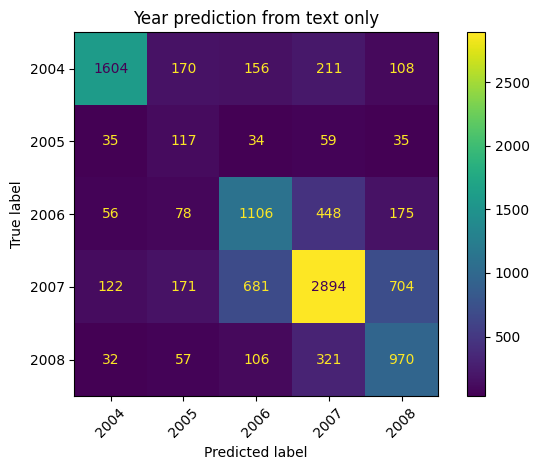

In [6]:
plt.figure(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
	y_te,
	pred,
	xticks_rotation=45,
	values_format="d"
)
plt.title("Year prediction from text only")
plt.tight_layout()
plt.show()